# ray3D: central ray-field workflow

This notebook is the 3D continuation of the Ray2D walkthrough. The first notebook explained how
better 2D correspondences help a classical pinhole stereo fit. This one asks the next question:

**what happens if we also replace the 3D camera model by a compact central ray-field backend?**

The underlying geometric object is a ray through a fixed camera center:

$$
\ell_p(t) = C + t\,\hat{\mathbf d}(u,v), \qquad
\hat{\mathbf d}(u,v) = \frac{[x(u,v),\,y(u,v),\,1]^\top}{\|[x(u,v),\,y(u,v),\,1]^\top\|}
$$

Compared with a pinhole model, the unknown is no longer only a matrix of intrinsics and a small
distortion vector. The mapping from pixel to direction is represented in a compact Zernike basis,
then optimized with point-to-ray consistency.

The notebook is organized as a progression from the cleanest benchmark to the most realistic one:

- Section 1: a **true Z-sweep** tailored to compare 3D backends fairly,
- Section 2: a **pose-sweep compression benchmark** where Pycaso becomes stressed,
- Section 3: the **full StereoComplex compression sweep**, which combines 2D and 3D effects,
- Section 4: one local corner overlay to reconnect the global curves to image-space measurements,
- Section 5: the public API entry point used to load an exported ray3D model.

As in the first notebook, we read only versioned JSON summaries and committed example assets. The
goal is explanation, not long recomputation.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

from stereocomplex.api.corner_refinement import refine_charuco_corners
from stereocomplex.core.image_io import load_gray_u8
from stereocomplex.eval.charuco_detection import _make_charuco_detector

plt.style.use('seaborn-v0_8-whitegrid')

def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').exists() and (p / 'README.md').exists():
            return p
    raise RuntimeError('Repository root not found')

ROOT = find_repo_root()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

def load_json(rel_path):
    return json.loads((ROOT / rel_path).read_text(encoding='utf-8'))

print('ROOT =', ROOT)

ROOT = /home/jeff/StereoComplex


## 0. What ray3D is trying to do

The ray3D backend is designed for a specific gap in standard stereo workflows:

- pinhole calibration is convenient and efficient,
- but under strong photometric stress or more complex optics, a rigid pinhole parameterization may
  absorb the wrong signal.

StereoComplex therefore keeps the pipeline modular:

1. first improve the 2D observations with Ray2D,
2. then optionally replace the classical pinhole 3D backend with a central ray-field model.

The fit itself is driven by **point-to-ray** consistency. Intuitively, the optimizer asks whether
the observed board points are explained by a coherent bundle of rays across both cameras, rather
than only by a small parametric projection model.

Right after loading the scene metadata, the notebook prints the exact synthetic setup:

- board geometry,
- camera model and effective focal length,
- baseline and stored rig parameters,
- and the photometric aberrations injected by the simulator.

The local overlay shown later in the notebook still matters, because ray3D is not magic: it is
fed by 2D corners. The reason to start from global plots is simply that the 3D claim must be
assessed on benchmark trends, not on one hand-picked image.

In [2]:
scene_dir = ROOT / 'dataset' / 'compression_sweep_pnp' / 'png_lossless' / 'train' / 'scene_0000'
meta = load_json(scene_dir / 'meta.json')
frames = [json.loads(line) for line in (scene_dir / 'frames.jsonl').read_text(encoding='utf-8').splitlines() if line.strip()]
gt = np.load(scene_dir / 'gt_charuco_corners.npz')

def print_synthetic_setup(meta):
    board = meta.get('board', {})
    sim = meta.get('sim_params', {})
    stereo = meta.get('stereo', {})
    left = stereo.get('left', {})
    sensor = left.get('sensor', {})
    image = left.get('image', {})
    f_um = sim.get('f_um')
    pixel_pitch_um = sensor.get('pixel_pitch_um')
    fx_px = f_um / pixel_pitch_um if f_um and pixel_pitch_um else None
    print('\nSynthetic setup summary')
    print('  board:')
    print(f"    type={board.get('type')}  dictionary={board.get('aruco_dictionary')}")
    print(f"    grid={board.get('squares_x')}x{board.get('squares_y')}  square={board.get('square_size_mm'):.2f} mm  marker={board.get('marker_size_mm'):.2f} mm")
    print('  intrinsics / optics:')
    print(f"    camera_model={sim.get('camera_model')}  f={f_um:.1f} um  pixel_pitch={pixel_pitch_um:.4f} um  f~{fx_px:.1f} px")
    print('  extrinsics / rig:')
    print(f"    baseline={sim.get('baseline_mm'):.2f} mm")
    print('  aberrations / degradations:')
    print(f"    distortion_model={sim.get('distortion_model')}  image_format={sim.get('image_format')}  outside_mask={sim.get('outside_mask')}")
    print(f"    blur_fwhm_um={sim.get('blur_fwhm_um'):.2f}  blur_edge_factor={sim.get('blur_edge_factor'):.2f}  blur_edge_start={sim.get('blur_edge_start'):.2f}  noise_std={sim.get('noise_std'):.3f}")
    print(f"    left_distortion={json.dumps(sim.get('distortion_left', {}), sort_keys=True)}")
    print(f"    right_distortion={json.dumps(sim.get('distortion_right', {}), sort_keys=True)}")
    print('  image setup:')
    print(f"    size={image.get('width_px')}x{image.get('height_px')} px  bit_depth={image.get('bit_depth')}  gamma={image.get('gamma')}  texture_interp={board.get('texture_interp')}")

cv2_obj, aruco, dictionary, board, detector_params, aruco_detector, charuco_detector = _make_charuco_detector(meta['board'])

def detect_charuco_view(img_gray):
    if charuco_detector is not None:
        charuco_corners, charuco_ids, marker_corners, marker_ids = charuco_detector.detectBoard(img_gray)
    else:
        if aruco_detector is not None:
            marker_corners, marker_ids, _rej = aruco_detector.detectMarkers(img_gray)
        else:
            marker_corners, marker_ids, _rej = aruco.detectMarkers(img_gray, dictionary, parameters=detector_params)
        charuco_corners, charuco_ids = None, None
        if hasattr(aruco, 'interpolateCornersCharuco') and marker_ids is not None and len(marker_ids) > 0:
            ret = aruco.interpolateCornersCharuco(marker_corners, marker_ids, img_gray, board)
            if ret is not None:
                if len(ret) == 3:
                    charuco_corners, charuco_ids, _ = ret
                elif len(ret) == 4:
                    _, charuco_corners, charuco_ids, _ = ret
    marker_ids_arr = np.asarray(marker_ids if marker_ids is not None else [], dtype=np.int32).reshape(-1)
    marker_corners_arr = [np.asarray(c, dtype=np.float64).reshape(-1, 2) for c in marker_corners] if marker_corners is not None else []
    charuco_ids_arr = np.asarray(charuco_ids if charuco_ids is not None else [], dtype=np.int32).reshape(-1)
    if charuco_corners is None or charuco_ids_arr.size == 0:
        charuco_xy = np.zeros((0, 2), dtype=np.float64)
    else:
        charuco_xy = np.asarray(charuco_corners, dtype=np.float64).reshape(-1, 2) - 0.5
    return {
        'marker_ids': marker_ids_arr,
        'marker_corners': marker_corners_arr,
        'charuco_ids': charuco_ids_arr,
        'charuco_xy': charuco_xy,
    }

def gt_map_for_frame_id(fid, side):
    frame_id = np.asarray(gt['frame_id'], dtype=np.int32).reshape(-1)
    corner_id = np.asarray(gt['corner_id'], dtype=np.int32).reshape(-1)
    uv = np.asarray(gt['uv_left_px'] if side == 'left' else gt['uv_right_px'], dtype=np.float64).reshape(-1, 2)
    mask = frame_id == int(fid)
    return {int(cid): uv[k] for k, cid in enumerate(corner_id[mask].tolist())}

def make_refined_points(det):
    refined = refine_charuco_corners(
        method='rayfield_tps_robust',
        board=board,
        marker_ids=det['marker_ids'],
        marker_corners=det['marker_corners'],
        charuco_ids=det['charuco_ids'],
        charuco_xy=det['charuco_xy'],
        tps_lam=10.0,
        huber_c=3.0,
        iters=3,
    )
    return np.asarray(refined, dtype=np.float64).reshape(-1, 2)

print('scene_dir =', scene_dir)
print('frames =', len(frames))
print('board type =', meta['board']['type'])
print_synthetic_setup(meta)

scene_dir = /home/jeff/StereoComplex/dataset/compression_sweep_pnp/png_lossless/train/scene_0000
frames = 8
board type = charuco


## 1. True Z-sweep benchmark: OpenCV, Pycaso, and ray3D

We start from the dedicated `PYCASO_Z_SWEEP` benchmark, where the board translates only along
$Z$ while the two cameras stay fixed. This protocol is intentionally simple:

- the board keeps the same in-plane geometry,
- only the depth changes,
- and the camera pair itself does not move.

This is the cleanest place to compare OpenCV, Pycaso-like polynomial backends, and ray3D because
the experiment is naturally aligned with Pycaso's preferred operating regime. If ray3D is
competitive here, the comparison is fair; if it is better later under harder perturbations, that
extra gain cannot be dismissed as a protocol mismatch.

What to look for in the next plots:

- the left panel shows how the RMS Z error evolves with depth,
- the right panel compresses that into one global RMS value per backend.

This section answers the baseline question: on clean, well-conditioned data, does ray3D stay in
the same accuracy range as the other methods?

method                    global RMS Z (mm)
OpenCV pinhole                     0.007192
Pycaso direct                      0.001465
Pycaso Soloff LM                   0.001554
ray3D fixed                        0.001556


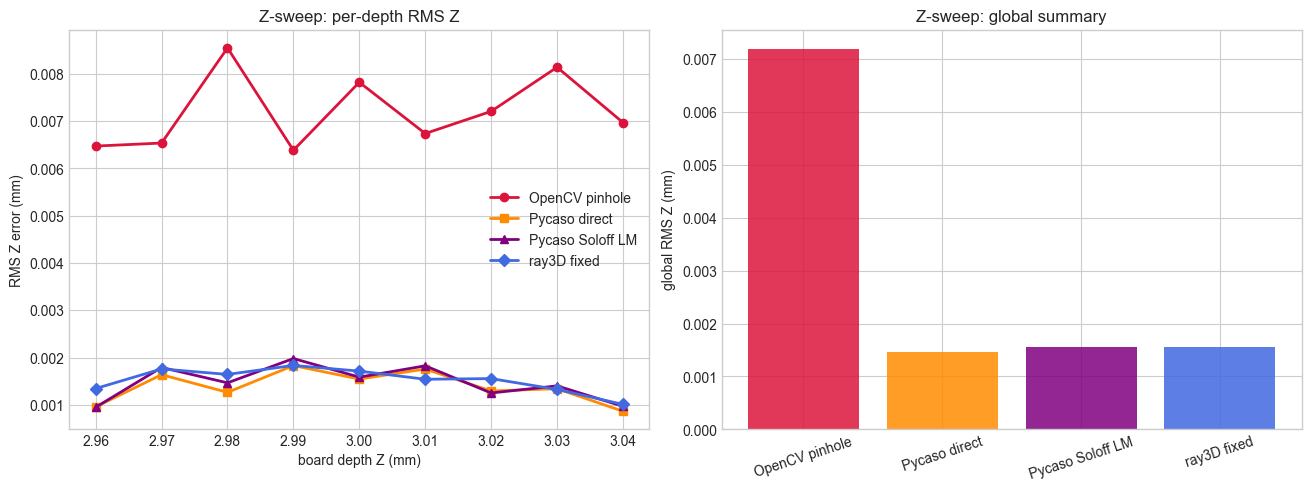

In [3]:
z_sweep = load_json('validation/z_sweep/pycaso_z_sweep_metrics_refined.json')

methods = [
    ('opencv_pinhole', 'OpenCV pinhole', 'crimson', 'o'),
    ('pycaso_direct_poly', 'Pycaso direct', 'darkorange', 's'),
    ('pycaso_soloff_lm', 'Pycaso Soloff LM', 'purple', '^'),
    ('rayfield3d_fixed', 'ray3D fixed', 'royalblue', 'D'),
]

print(f"{'method':24s} {'global RMS Z (mm)':>18s}")
for key, label, _color, _marker in methods:
    print(f"{label:24s} {float(z_sweep[key]['rms_z_mm']):18.6f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)

for key, label, color, marker in methods:
    by_depth = z_sweep[key]['by_depth']
    depth_mm = np.asarray(by_depth['depth_mm'], dtype=float)
    rms_mm = np.asarray(by_depth['rms'], dtype=float)
    axes[0].plot(depth_mm, rms_mm, marker=marker, color=color, linewidth=2, label=label)

axes[0].set_xlabel('board depth Z (mm)')
axes[0].set_ylabel('RMS Z error (mm)')
axes[0].set_title('Z-sweep: per-depth RMS Z')
axes[0].legend()

labels = [label for _key, label, _color, _marker in methods]
values = [float(z_sweep[key]['rms_z_mm']) for key, _label, _color, _marker in methods]
colors = [color for _key, _label, color, _marker in methods]
axes[1].bar(labels, values, color=colors, alpha=0.85)
axes[1].set_ylabel('global RMS Z (mm)')
axes[1].set_title('Z-sweep: global summary')
axes[1].tick_params(axis='x', rotation=18)

plt.show()


## 2. Global compression pose-sweep: Pycaso vs ray3D

The next plot switches to the published **pose-sweep compression benchmark**, which is harder and
more revealing.

Here the board is no longer limited to a pure depth translation. The pose set explores a broader
family of configurations, while codec degradations perturb the underlying 2D observations.

This regime is especially informative for polynomial direct mappings such as Pycaso:

- they can be very strong in a well-matched sweep protocol,
- but they become more fragile when the observation manifold broadens and the image evidence is
  perturbed.

Each point in the figure is one codec setting. The ratio plot on the right is important: it tells
you not only that ray3D is smaller, but **by how much** the error is reduced for each degradation
level.

codec             Pycaso direct (%)    ray3D fixed (%)       gain x
png lossless               1.475090           0.106430        13.86
webp q70                   0.944502           0.092001        10.27
webp q80                   1.936886           0.101855        19.02
webp q90                   1.268087           0.103398        12.26
webp q95                   3.136666           0.104977        29.88
jpeg q80                   2.535790           0.100258        25.29
jpeg q90                   2.291630           0.104354        21.96
jpeg q95                   2.595607           0.109753        23.65
jpeg q98                   4.072583           0.101086        40.29


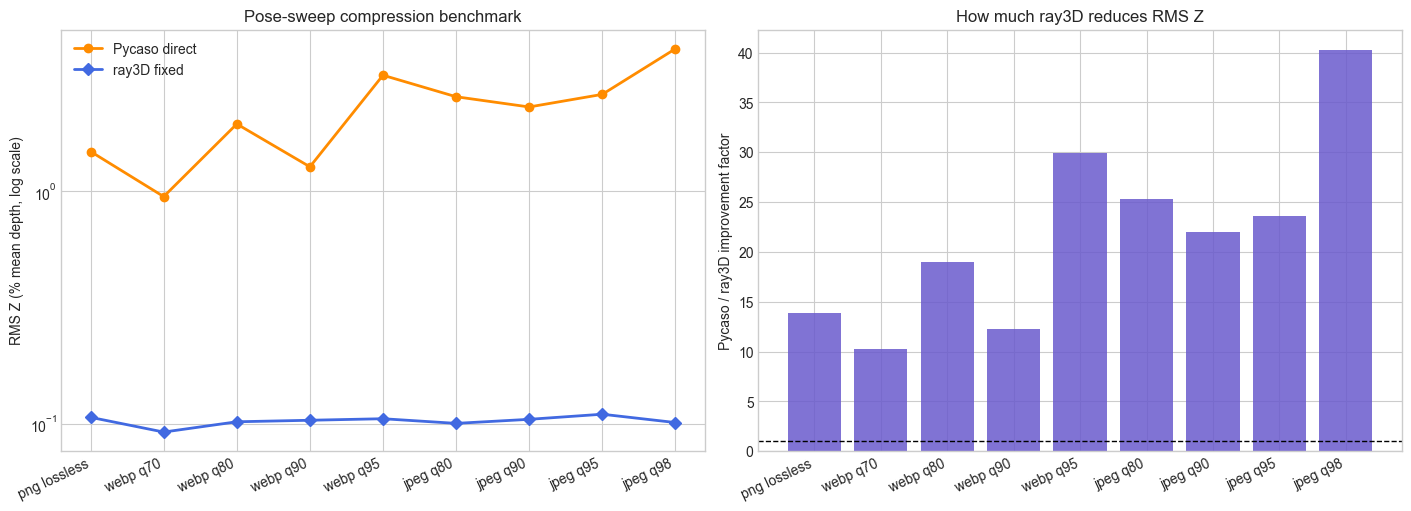

In [4]:
pose = load_json('paper/tables/pycaso_pose_sweep_sweep_summary.json')

codec_order = ['png_lossless', 'webp_q70', 'webp_q80', 'webp_q90', 'webp_q95', 'jpeg_q80', 'jpeg_q90', 'jpeg_q95', 'jpeg_q98']
labels = [c.replace('_', ' ') for c in codec_order]
pycaso_rel = np.array([float(pose['cases'][c]['metrics']['pycaso_direct_poly']['rms_z_rel_percent']) for c in codec_order], dtype=float)
ray3d_rel = np.array([float(pose['cases'][c]['metrics']['rayfield3d_fixed']['rms_z_rel_percent']) for c in codec_order], dtype=float)
gain = pycaso_rel / ray3d_rel

print(f"{'codec':16s} {'Pycaso direct (%)':>18s} {'ray3D fixed (%)':>18s} {'gain x':>12s}")
for label, p, r, g in zip(labels, pycaso_rel, ray3d_rel, gain, strict=True):
    print(f"{label:16s} {p:18.6f} {r:18.6f} {g:12.2f}")

x = np.arange(len(labels))
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
axes[0].plot(x, pycaso_rel, marker='o', color='darkorange', linewidth=2, label='Pycaso direct')
axes[0].plot(x, ray3d_rel, marker='D', color='royalblue', linewidth=2, label='ray3D fixed')
axes[0].set_yscale('log')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=25, ha='right')
axes[0].set_ylabel('RMS Z (% mean depth, log scale)')
axes[0].set_title('Pose-sweep compression benchmark')
axes[0].legend()

axes[1].bar(x, gain, color='slateblue', alpha=0.85)
axes[1].axhline(1.0, color='k', linestyle='--', linewidth=1)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=25, ha='right')
axes[1].set_ylabel('Pycaso / ray3D improvement factor')
axes[1].set_title('How much ray3D reduces RMS Z')

plt.show()


## 3. Full compression sweep in the stereo pipeline

This last global plot puts ray3D back into the full StereoComplex story.
We now compare three full pipelines across all released codec settings:

- raw pinhole,
- pinhole + Ray2D,
- ray3D + Ray2D.

This section is useful because it separates two questions that are easy to confuse:

- how much is already gained by improving the 2D inputs?
- what additional robustness comes from changing the 3D backend itself?

In practice, the expected reading is:

- raw pinhole gives the reference baseline,
- pinhole + Ray2D shows what better correspondences alone buy you,
- ray3D + Ray2D shows whether the central ray-field backend remains more stable under aggressive
  codec perturbations.

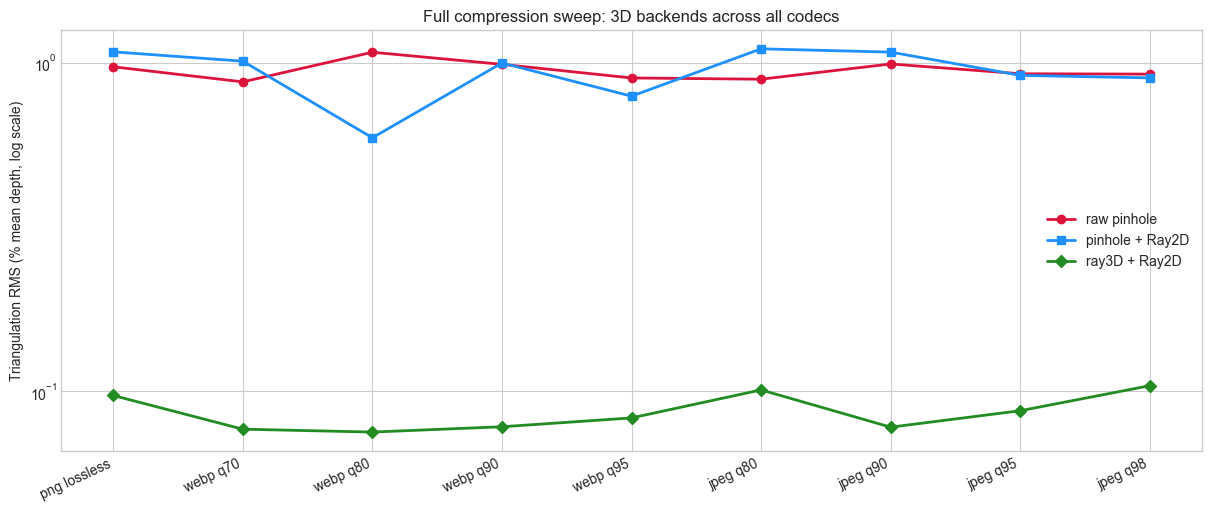

codec               raw pinhole    pinhole+Ray2D    ray3D+Ray2D
png lossless           0.971317         1.078550       0.097115
webp q70               0.873835         1.010289       0.076689
webp q80               1.075540         0.590697       0.075156
webp q90               0.988120         0.997639       0.078000
webp q95               0.898191         0.790563       0.082988
jpeg q80               0.890371         1.101527       0.100979
jpeg q90               0.990716         1.076619       0.077788
jpeg q95               0.924957         0.914717       0.087273
jpeg q98               0.922722         0.898524       0.104009


In [5]:
sweep3d = load_json('docs/assets/compression_sweep/sweep_metrics.json')
codec_order = ['png_lossless', 'webp_q70', 'webp_q80', 'webp_q90', 'webp_q95', 'jpeg_q80', 'jpeg_q90', 'jpeg_q95', 'jpeg_q98']
labels = [c.replace('_', ' ') for c in codec_order]
methods = [
    ('opencv_pinhole_raw', 'raw pinhole', 'crimson', 'o'),
    ('opencv_pinhole_rayfield2d', 'pinhole + Ray2D', 'dodgerblue', 's'),
    ('rayfield3d_ba_rayfield2d', 'ray3D + Ray2D', 'forestgreen', 'D'),
]

fig, ax = plt.subplots(1, 1, figsize=(12, 5), constrained_layout=True)
x = np.arange(len(codec_order))
for key, label, color, marker in methods:
    vals = np.array([float(sweep3d['cases'][c][key]['tri_rms_rel_depth_percent']) for c in codec_order], dtype=float)
    ax.plot(x, vals, marker=marker, color=color, linewidth=2, label=label)

ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha='right')
ax.set_ylabel('Triangulation RMS (% mean depth, log scale)')
ax.set_title('Full compression sweep: 3D backends across all codecs')
ax.legend()
plt.show()

print(f"{'codec':16s} {'raw pinhole':>14s} {'pinhole+Ray2D':>16s} {'ray3D+Ray2D':>14s}")
for c, label in zip(codec_order, labels, strict=True):
    row = sweep3d['cases'][c]
    print(f"{label:16s} {float(row['opencv_pinhole_raw']['tri_rms_rel_depth_percent']):14.6f} {float(row['opencv_pinhole_rayfield2d']['tri_rms_rel_depth_percent']):16.6f} {float(row['rayfield3d_ba_rayfield2d']['tri_rms_rel_depth_percent']):14.6f}")


## 4. Local corner view: what enters the 3D fit

The global curves above are the real evidence, but it is still useful to reconnect them to the
raw image domain.

The ray3D fit is ultimately driven by 2D corners. This local view therefore shows one stereo pair
and one corner where the Ray2D preprocessing moves the observation before the 3D backend sees it.

Read this panel as a reminder of the full logic:

- ray3D is a 3D model,
- but its stability still depends on the quality of the image-space measurements,
- which is why Ray2D and ray3D are complementary rather than competing ideas.

Chosen left corner id = 43
Chosen right corner id = 25


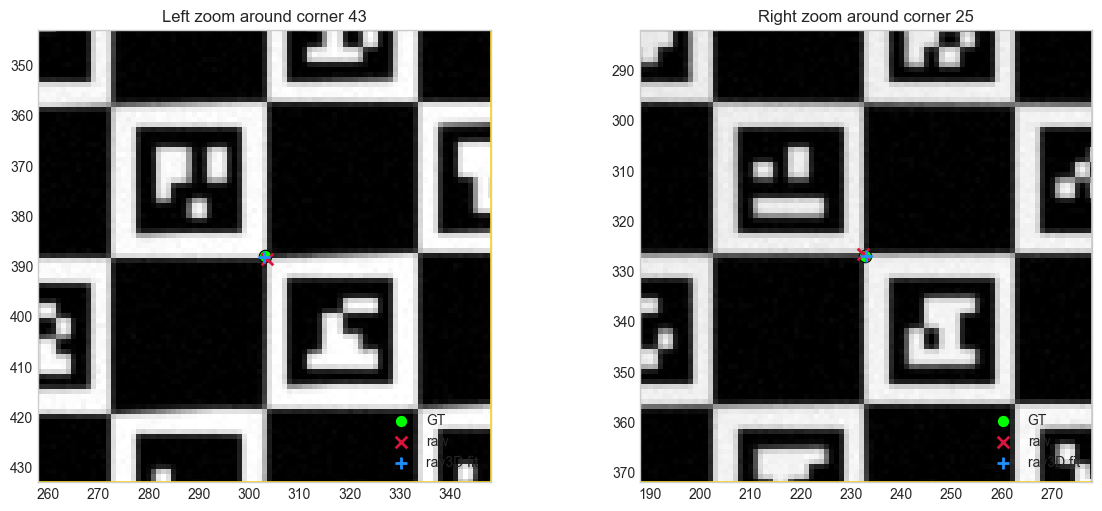

In [6]:
frame0 = frames[0]
left_img = load_gray_u8(scene_dir / 'left' / frame0['left'])
right_img = load_gray_u8(scene_dir / 'right' / frame0['right'])
det_left = detect_charuco_view(left_img)
det_right = detect_charuco_view(right_img)
ref_left = make_refined_points(det_left)
ref_right = make_refined_points(det_right)
gt_left = gt_map_for_frame_id(int(frame0['frame_id']), 'left')
gt_right = gt_map_for_frame_id(int(frame0['frame_id']), 'right')

def choose_corner(det, ref, gt_map):
    ids = det['charuco_ids']
    raw = det['charuco_xy']
    common = [int(cid) for cid in ids.tolist() if int(cid) in gt_map]
    id_to_idx = {int(cid): i for i, cid in enumerate(ids.tolist())}
    shifts = []
    for cid in common:
        i = id_to_idx[cid]
        shifts.append((float(np.linalg.norm(ref[i] - raw[i])), cid))
    return max(shifts)[1]

corner_id_L = choose_corner(det_left, ref_left, gt_left)
corner_id_R = choose_corner(det_right, ref_right, gt_right)
print('Chosen left corner id =', corner_id_L)
print('Chosen right corner id =', corner_id_R)

def plot_zoom(ax, img, title, gt_pt, raw_pt, ref_pt, radius=45):
    h, w = img.shape[:2]
    x, y = float(gt_pt[0]), float(gt_pt[1])
    x0 = max(0, int(round(x - radius)))
    x1 = min(w, int(round(x + radius)))
    y0 = max(0, int(round(y - radius)))
    y1 = min(h, int(round(y + radius)))
    ax.imshow(img, cmap='gray', origin='upper')
    ax.set_xlim(x0, x1)
    ax.set_ylim(y1, y0)
    ax.scatter([gt_pt[0]], [gt_pt[1]], s=80, c='lime', marker='o', edgecolors='black', linewidths=0.8, label='GT')
    ax.scatter([raw_pt[0]], [raw_pt[1]], s=70, c='crimson', marker='x', linewidths=2.0, label='raw')
    ax.scatter([ref_pt[0]], [ref_pt[1]], s=70, c='dodgerblue', marker='+', linewidths=2.0, label='ray3D fit')
    ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor='gold', linewidth=1.2))
    ax.set_title(title)
    ax.legend(loc='lower right')
    ax.grid(False)

id_to_idx_L = {int(cid): i for i, cid in enumerate(det_left['charuco_ids'].tolist())}
id_to_idx_R = {int(cid): i for i, cid in enumerate(det_right['charuco_ids'].tolist())}
raw_L = det_left['charuco_xy'][id_to_idx_L[corner_id_L]]
ref_L = ref_left[id_to_idx_L[corner_id_L]]
gt_L = gt_left[corner_id_L]
raw_R = det_right['charuco_xy'][id_to_idx_R[corner_id_R]]
ref_R = ref_right[id_to_idx_R[corner_id_R]]
gt_R = gt_right[corner_id_R]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
plot_zoom(axes[0], left_img, f'Left zoom around corner {corner_id_L}', gt_L, raw_L, ref_L)
plot_zoom(axes[1], right_img, f'Right zoom around corner {corner_id_R}', gt_R, raw_R, ref_R)
plt.show()

## 5. API entry point

The ray3D backend is meant to be used as a compact exported model, not only as an experiment
script result.

The code below is therefore intentionally small and safe:

- it loads an exported ray-field model if one exists in your checkout,
- it inspects the available metadata,
- and it shows the public entry point that downstream code should rely on.

This is the bridge from the benchmark world to actual use: once the model is exported, the rest of
the pipeline can interact with a stable API instead of reconstructing the calibration state by
hand.

In [7]:
from stereocomplex.api import load_stereo_central_rayfield

model_dir = ROOT / 'models' / 'scene0000_rayfield3d'
if model_dir.exists():
    model = load_stereo_central_rayfield(model_dir)
    uvL = np.array([[320.0, 240.0]], dtype=float)
    uvR = np.array([[318.5, 240.0]], dtype=float)
    xyz_mm, skew_mm = model.triangulate(uvL, uvR)
    print('XYZ_mm =', xyz_mm)
    print('skew_mm =', skew_mm)
else:
    print('No exported model found at', model_dir)
    print('Run the calibration script first if you want to instantiate the API.')

print('\nTo export a model from images, use:')
print('  .venv/bin/python paper/experiments/calibrate_central_rayfield3d_from_images.py dataset/compression_sweep_pnp/png_lossless --split train --scene scene_0000 --max-frames 5 --method2d rayfield_tps_robust --nmax 10 --lam-coeff 1e-3 --outer-iters 3 --out paper/tables/rayfield3d_ba_scene0000.json --export-model models/scene0000_rayfield3d')
print('\nThen evaluate it with:')
print('  .venv/bin/python docs/examples/reconstruction_api_demo.py dataset/compression_sweep_pnp/png_lossless --split train --scene scene_0000 --max-frames 5 --model models/scene0000_rayfield3d')

No exported model found at /home/jeff/StereoComplex/models/scene0000_rayfield3d
Run the calibration script first if you want to instantiate the API.

To export a model from images, use:
  .venv/bin/python paper/experiments/calibrate_central_rayfield3d_from_images.py dataset/compression_sweep_pnp/png_lossless --split train --scene scene_0000 --max-frames 5 --method2d rayfield_tps_robust --nmax 10 --lam-coeff 1e-3 --outer-iters 3 --out paper/tables/rayfield3d_ba_scene0000.json --export-model models/scene0000_rayfield3d

Then evaluate it with:
  .venv/bin/python docs/examples/reconstruction_api_demo.py dataset/compression_sweep_pnp/png_lossless --split train --scene scene_0000 --max-frames 5 --model models/scene0000_rayfield3d
